<a href="https://colab.research.google.com/github/rtaqag35/ThinPrep-Deep-Learning-Project/blob/main/ThinPrep_Deep_Learning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import zipfile, os

# Include the dataset as a zipfile in the execution environment
zip_name = "Thin_Prep_Dataset.zip"


if not os.path.exists("dataset/"):
    os.makedirs("dataset/")

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall("dataset/")

print(os.listdir("dataset/"))

['LSIL (131).JPG', 'HSIL (6).JPG', 'NIL (90).JPG', 'HSIL (146).JPG', 'NIL (94).JPG', 'HSIL (113).JPG', 'HSIL (131).JPG', 'NIL (147).JPG', 'HSIL (1).JPG', 'NIL (185).jpg', 'NIL (56).jpg', 'LSIL (2).jpg', 'HSIL (144).JPG', 'NIL (136).JPG', 'NIL (57).jpg', 'HSIL (93).JPG', 'LSIL (135).JPG', 'LSIL (19).jpg', 'LSIL (130).JPG', 'NIL (77).JPG', 'HSIL (122).JPG', 'NIL (15).jpg', 'HSIL (49).jpg', 'HSIL (81).JPG', 'NIL (74).JPG', 'HSIL (21).JPG', 'LSIL (182).jpg', 'NIL (187).jpg', 'LSIL (171).JPG', 'HSIL (111).JPG', 'HSIL (10).JPG', 'LSIL (102).jpg', 'HSIL (158).JPG', 'HSIL (101).JPG', 'NIL (139).JPG', 'NIL (6).jpg', 'LSIL (34).jpg', 'NIL (46).jpg', 'LSIL (118).JPG', 'LSIL (50).jpg', 'HSIL (60).jpg', 'HSIL (41).jpg', 'HSIL (98).JPG', 'LSIL (45).jpg', 'LSIL (180).jpg', 'LSIL (37).jpg', 'NIL (44).jpg', 'HSIL (194).JPG', 'LSIL (121).JPG', 'NIL (13).jpg', 'LSIL (31).jpg', 'NIL (153).JPG', 'HSIL (17).JPG', 'NIL (25).jpg', 'LSIL (33).jpg', 'NIL (180).JPG', 'HSIL (163).JPG', 'LSIL (114).JPG', 'HSIL (62

In [4]:
import os, re, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

In [5]:

from PIL import Image
import torch
from torch.utils.data import TensorDataset, DataLoader
from torchvision import transforms


SEED = 42
IMG_DIR   = "dataset/"
IMG_SIZE  = (224, 224)
BATCH     = 32
CLASS_NAMES = ["HSIL", "LSIL", "NIL"]
NUM_CLASSES = 3
EPOCHS = 30

# Class to integer mapping
CLASS_MAP = {"HSIL": 0, "LSIL": 1, "NIL": 2}

# ImageNet normalization
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    ),
])


image_tensors = []
label_tensors = []
skipped       = []

for fname in sorted(os.listdir(IMG_DIR)):
    if not fname.upper().endswith(".JPG"):
        continue

    # Class extraction
    match = re.match(r"^(HSIL|LSIL|NIL)\s*\(", fname, re.IGNORECASE)
    if match is None:
        skipped.append(fname)
        continue

    class_name = match.group(1).upper()
    label      = CLASS_MAP[class_name]

    img_path = os.path.join(IMG_DIR, fname)
    img      = Image.open(img_path).convert("RGB")
    tensor   = transform(img)

    image_tensors.append(tensor)
    label_tensors.append(label)


X = torch.stack(image_tensors)
y = torch.tensor(label_tensors, dtype=torch.long)

print(f"Images loaded : {X.shape}")
print(f"Labels shape  : {y.shape}")
print(f"Label counts  : { {k: (y==v).sum().item() for k,v in CLASS_MAP.items()} }")
if skipped:
    print(f"Skipped files : {skipped}")

Images loaded : torch.Size([600, 3, 224, 224])
Labels shape  : torch.Size([600])
Label counts  : {'HSIL': 200, 'LSIL': 200, 'NIL': 200}


In [6]:
print("Unique labels in y:", np.unique(y, return_counts=True))
print("Expected: (array([0, 1, 2]), array([200, 200, 200]))") #debugging

Unique labels in y: (array([0, 1, 2]), array([200, 200, 200]))
Expected: (array([0, 1, 2]), array([200, 200, 200]))


In [7]:
dataset    = TensorDataset(X, y)

# 80/20 train-validation split
val_size   = int(0.2 * len(dataset))
train_size = len(dataset) - val_size
train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False)

# Verify one batch
imgs, labels = next(iter(train_loader))
print(f"Batch images : {imgs.shape}")
print(f"Batch labels : {labels.shape}")

Batch images : torch.Size([32, 3, 224, 224])
Batch labels : torch.Size([32])


In [8]:

IMG_DIR = "dataset/"
PATTERN = re.compile(r"^(HSIL|LSIL|NIL)\s*\(", re.IGNORECASE)

images, labels_raw = [], []

for fname in sorted(os.listdir(IMG_DIR)):
    if not fname.upper().endswith(".JPG"):
        continue
    m = PATTERN.match(fname)
    if m is None:
        continue

    class_name = m.group(1).upper()

    if class_name not in CLASS_MAP:
        continue

    img_path  = os.path.join(IMG_DIR, fname)
    img       = keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_array = keras.utils.img_to_array(img)

    images.append(img_array)
    labels_raw.append(CLASS_MAP[class_name])

X_raw = np.array(images, dtype="float32")
y     = np.array(labels_raw, dtype="int32")

print(f"Loaded: {X_raw.shape}  |  Labels: {y.shape}")
print(f"Class counts: { {CLASS_NAMES[i]: int((y==i).sum()) for i in range(NUM_CLASSES)} }")

Loaded: (600, 224, 224, 3)  |  Labels: (600,)
Class counts: {'HSIL': 200, 'LSIL': 200, 'NIL': 200}


In [9]:

from sklearn.model_selection import StratifiedShuffleSplit

y = np.array(labels_raw, dtype="int32")

print("y before split:", np.unique(y, return_counts=True))

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
trainval_idx, test_idx = next(sss1.split(X_raw, y))

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.176, random_state=SEED)
train_sub, val_sub = next(sss2.split(trainval_idx, y[trainval_idx]))
train_idx = trainval_idx[train_sub]
val_idx   = trainval_idx[val_sub]

X_train_raw, y_train = X_raw[train_idx], y[train_idx]
X_val_raw,   y_val   = X_raw[val_idx],   y[val_idx]
X_test_raw,  y_test  = X_raw[test_idx],  y[test_idx]

for split_name, split_y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    counts = {CLASS_NAMES[i]: int((split_y == i).sum()) for i in range(NUM_CLASSES)}
    print(f"{split_name}: {counts}")

y before split: (array([0, 1, 2], dtype=int32), array([200, 200, 200]))
train: {'HSIL': 140, 'LSIL': 140, 'NIL': 140}
val: {'HSIL': 30, 'LSIL': 30, 'NIL': 30}
test: {'HSIL': 30, 'LSIL': 30, 'NIL': 30}


In [10]:
X_train = preprocess_input(X_train_raw.copy())
X_val   = preprocess_input(X_val_raw.copy())
X_test  = preprocess_input(X_test_raw.copy())

y_train_oh = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh   = keras.utils.to_categorical(y_val,   NUM_CLASSES)
y_test_oh  = keras.utils.to_categorical(y_test,  NUM_CLASSES)

In [11]:
'''
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="augmentation")
'''

'\ndata_augmentation = keras.Sequential([\n    layers.RandomFlip("horizontal_and_vertical"),\n    layers.RandomRotation(0.15),\n    layers.RandomZoom(0.1),\n    layers.RandomContrast(0.1),\n], name="augmentation")\n'

In [12]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
    layers.RandomTranslation(0.1, 0.1),
])

In [13]:
IMG_SIZE = 224 #works better than a tuple for the next step

In [14]:
def build_feature_extraction_model(num_classes=NUM_CLASSES):
    backbone = EfficientNetB3(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        pooling=None,
    )
    backbone.trainable = False

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")

    x = data_augmentation(inputs)

    x = backbone(x, training=False)

    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.BatchNormalization(name="head_bn")(x)
    x = layers.Dense(256, activation="relu", name="head_dense")(x)
    x = layers.Dropout(0.5, name="head_dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = Model(inputs, outputs, name="efficientnet_feature_extraction")
    return model, backbone


model, backbone = build_feature_extraction_model()


trainable   = sum(np.prod(v.shape) for v in model.trainable_weights)
frozen      = sum(np.prod(v.shape) for v in model.non_trainable_weights)
print(f"\nTrainable params   : {trainable:,}")
print(f"Non-trainable params: {frozen:,}")
print(f"(Backbone frozen: {not backbone.trainable})")
model.summary(line_length=80)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Trainable params   : 397,315
Non-trainable params: 10,786,607.0
(Backbone frozen: True)


Model: "efficientnet_feature_extraction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)          │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ sequential (Sequential)           │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)       │ (None, 7, 7, 1536)       │    10,783,535 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)      │ (None, 1536)             │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ head_bn (BatchNormalization)      │ (None, 1536)             │         6,144 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ head_dense (Dense)                │ (None, 256)              │       393,472 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ head_dropout (Dropout)            │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ predictions (Dense)               │ (None, 3)                │           771 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 11,183,922 (42.66 MB)

 Trainable params: 397,315 (1.52 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

In [15]:
for i, name in enumerate(CLASS_NAMES):
    print(f"{name}: train={int((y_train==i).sum())}  val={int((y_val==i).sum())}  test={int((y_test==i).sum())}")

HSIL: train=140  val=30  test=30
LSIL: train=140  val=30  test=30
NIL: train=140  val=30  test=30


In [16]:

IMG_DIR = "dataset/"
PATTERN = re.compile(r"^(HSIL|LSIL|NIL)\s*\(", re.IGNORECASE)

found = {"HSIL": 0, "LSIL": 0, "NIL": 0, "other": 0}
sample_names = []

for fname in sorted(os.listdir(IMG_DIR)):
    if not fname.upper().endswith(".JPG"):
        continue
    m = PATTERN.match(fname)
    if m:
        found[m.group(1).upper()] += 1
    else:
        found["other"] += 1
        sample_names.append(fname)

print("Raw filename matches:", found)
print("Unmatched samples:", sample_names[:5])

Raw filename matches: {'HSIL': 200, 'LSIL': 200, 'NIL': 200, 'other': 0}
Unmatched samples: []


In [17]:
from sklearn.utils.class_weight import compute_class_weight
cw_values = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=y_train)
class_weight = dict(enumerate(cw_values))
print(f"\nClass weights: { {CLASS_NAMES[i]: round(cw_values[i], 3) for i in range(NUM_CLASSES)} }")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    EarlyStopping(
        monitor="val_loss", patience=7, restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1
    ),
    ModelCheckpoint(
        "best_feature_extraction.keras",
        monitor="val_loss", save_best_only=True, verbose=0
    ),
]

print("\n── Phase 1: Training classifier head (backbone frozen) ──")
history_phase1 = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=EPOCHS,
    batch_size=BATCH,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)


Class weights: {'HSIL': np.float64(1.0), 'LSIL': np.float64(1.0), 'NIL': np.float64(1.0)}

── Phase 1: Training classifier head (backbone frozen) ──
Epoch 1/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 109s 6s/step - accuracy: 0.5190 - loss: 1.5408 - val_accuracy: 0.5222 - val_loss: 0.9732 - learning_rate: 0.0010
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 78s 6s/step - accuracy: 0.6310 - loss: 1.2145 - val_accuracy: 0.5889 - val_loss: 0.8559 - learning_rate: 0.0010
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 75s 5s/step - accuracy: 0.6381 - loss: 1.0871 - val_accuracy: 0.6556 - val_loss: 0.8081 - learning_rate: 0.0010
Epoch 4/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 83s 6s/step - accuracy: 0.6619 - loss: 1.0231 - val_accuracy: 0.6000 - val_loss: 0.8655 - learning_rate: 0.0010
Epoch 5/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 84s 6s/step - accuracy: 0.6286 - loss: 0.9274 - val_accuracy: 0.5333 - val_loss: 0.9171 - learning_rate: 0.0010
Epoch 6/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 84s 6s/step - accuracy: 0.6857 - loss: 0.9589 - val_accuracy:

In [18]:
FINE_TUNE_EPOCHS = 20
FINE_TUNE_AT     = len(backbone.layers) - 20

print(f"\n── Phase 2: Fine-tuning top {len(backbone.layers) - FINE_TUNE_AT} backbone layers ──")
backbone.trainable = True


for layer in backbone.layers[:FINE_TUNE_AT]:
    layer.trainable = False

trainable_ft = sum(np.prod(v.shape) for v in model.trainable_weights)
print(f"Trainable params after unfreezing: {trainable_ft:,}")


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks_ft = [
    EarlyStopping(
        monitor="val_loss", patience=7, restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4, min_lr=1e-7, verbose=1
    ),
    ModelCheckpoint(
        "best_fine_tuned.keras",
        monitor="val_loss", save_best_only=True, verbose=0
    ),
]

history_phase2 = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=FINE_TUNE_EPOCHS,
    batch_size=BATCH,
    class_weight=class_weight,
    callbacks=callbacks_ft,
    verbose=1,
)


── Phase 2: Fine-tuning top 20 backbone layers ──
Trainable params after unfreezing: 3,770,467
Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 114s 6s/step - accuracy: 0.7500 - loss: 0.7359 - val_accuracy: 0.7111 - val_loss: 0.6985 - learning_rate: 1.0000e-04
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 148s 7s/step - accuracy: 0.7262 - loss: 0.7704 - val_accuracy: 0.7333 - val_loss: 0.6763 - learning_rate: 1.0000e-04
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 92s 7s/step - accuracy: 0.7595 - loss: 0.7332 - val_accuracy: 0.7333 - val_loss: 0.6695 - learning_rate: 1.0000e-04
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 82s 6s/step - accuracy: 0.7524 - loss: 0.6596 - val_accuracy: 0.7333 - val_loss: 0.7030 - learning_rate: 1.0000e-04
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 90s 7s/step - accuracy: 0.7381 - loss: 0.7407 - val_accuracy: 0.7222 - val_loss: 0.7332 - learning_rate: 1.0000e-04
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 83s 6s/step - accuracy: 0.7476 - loss: 0.6476 - val_accuracy: 0.7222 - val_loss: 0.7555 - lear

In [19]:
def predict_with_tta(model, images, n_augments=10):
    aug = data_augmentation
    probs = np.zeros((len(images), NUM_CLASSES))
    for _ in range(n_augments):
        probs += model.predict(aug(images, training=True), verbose=0)
    return probs / n_augments

y_prob_tta = predict_with_tta(model, X_test)
y_pred_tta = np.argmax(y_prob_tta, axis=1)

In [ ]:

y_prob  = model.predict(X_test, verbose=0)
y_pred  = np.argmax(y_prob, axis=1)

print("\n" + "="*55)
print("  TEST SET RESULTS")
print("="*55)
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
macro_auc  = roc_auc_score(y_test_bin, y_prob, average="macro", multi_class="ovr")
print(f"  Macro AUC : {macro_auc:.4f}")

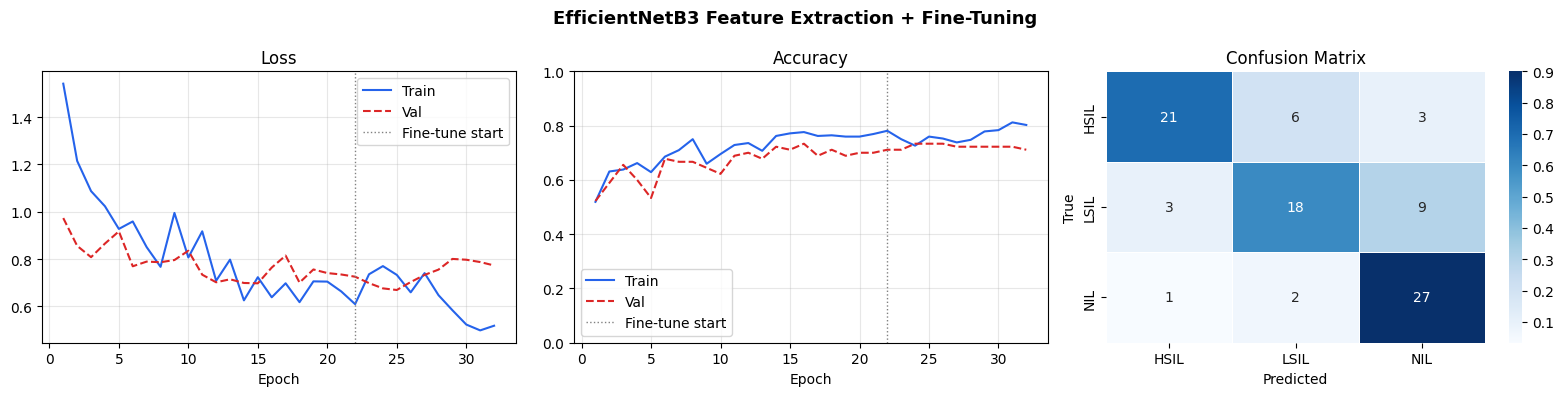

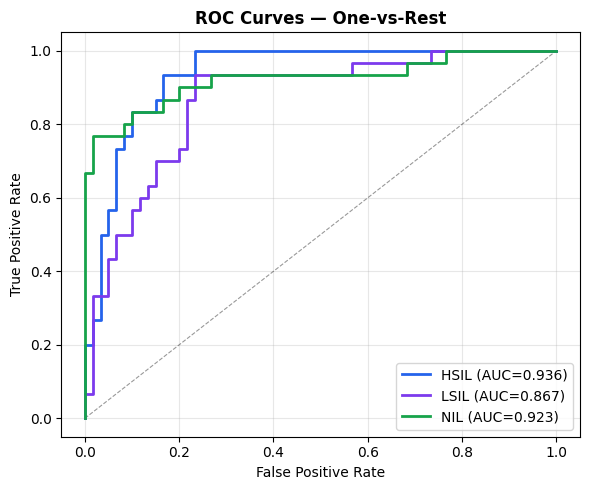

In [21]:
def merge_history(h1, h2):
    combined = {}
    for k in h1.history:
        combined[k] = h1.history[k] + h2.history[k]
    return combined

full_hist = merge_history(history_phase1, history_phase2)
phase1_end = len(history_phase1.history["loss"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("EfficientNetB3 Feature Extraction + Fine-Tuning", fontsize=13, fontweight="bold")
ep = range(1, len(full_hist["loss"]) + 1)

# Loss
axes[0].plot(ep, full_hist["loss"],     label="Train", color="#2563EB")
axes[0].plot(ep, full_hist["val_loss"], label="Val",   color="#DC2626", linestyle="--")
axes[0].axvline(phase1_end, color="gray", linestyle=":", linewidth=1, label="Fine-tune start")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(ep, full_hist["accuracy"],     label="Train", color="#2563EB")
axes[1].plot(ep, full_hist["val_accuracy"], label="Val",   color="#DC2626", linestyle="--")
axes[1].axvline(phase1_end, color="gray", linestyle=":", linewidth=1, label="Fine-tune start")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)

# Confusion matrix
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[2], linewidths=0.5, linecolor="white")
axes[2].set_title("Confusion Matrix")
axes[2].set_ylabel("True"); axes[2].set_xlabel("Predicted")

plt.tight_layout()
plt.savefig("efficientnet_results.png", dpi=150, bbox_inches="tight")
plt.show()

# ROC curves
fig, ax = plt.subplots(figsize=(6, 5))
colors = ["#2563EB", "#7C3AED", "#16A34A"]
ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.4)
for i, (cls, col) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    ax.plot(fpr, tpr, color=col, lw=2, label=f"{cls} (AUC={auc(fpr, tpr):.3f})")
ax.set_title("ROC Curves — One-vs-Rest", fontweight="bold")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("efficientnet_roc.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

def build_vgg_model(num_classes=NUM_CLASSES):

    backbone = VGG16(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    backbone.trainable = False

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")

    x = data_augmentation(inputs)
    x = backbone(x, training=False)

    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.BatchNormalization(name="head_bn")(x)
    x = layers.Dense(256, activation="relu", name="head_dense_1")(x)
    x = layers.Dropout(0.5, name="dropout_1")(x)
    x = layers.Dense(128, activation="relu", name="head_dense_2")(x)
    x = layers.Dropout(0.3, name="dropout_2")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = Model(inputs, outputs, name="vgg16_feature_extraction")
    return model, backbone


model, backbone = build_vgg_model()

trainable = sum(np.prod(v.shape) for v in model.trainable_weights)
frozen    = sum(np.prod(v.shape) for v in model.non_trainable_weights)
print(f"Trainable params    : {trainable:,}")
print(f"Non-trainable params: {frozen:,}")
model.summary(line_length=80)

In [23]:
from tensorflow.keras.applications.vgg16 import preprocess_input

X_train = preprocess_input(X_train_raw.copy())
X_val   = preprocess_input(X_val_raw.copy())
X_test  = preprocess_input(X_test_raw.copy())

In [24]:
backbone.trainable = True

for layer in backbone.layers:
    layer.trainable = False

for layer in backbone.layers:
    if "block5" in layer.name:
        layer.trainable = True

trainable_ft = sum(np.prod(v.shape) for v in model.trainable_weights)
print(f"Trainable params after unfreezing block5: {trainable_ft:,}")


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

Trainable params after unfreezing block5: 7,245,059


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
cw_values = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=y_train)
class_weight = dict(enumerate(cw_values))
print(f"\nClass weights: { {CLASS_NAMES[i]: round(cw_values[i], 3) for i in range(NUM_CLASSES)} }")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    EarlyStopping(
        monitor="val_loss", patience=7, restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1
    ),
    ModelCheckpoint(
        "best_feature_extraction.keras",
        monitor="val_loss", save_best_only=True, verbose=0
    ),
]

print("\n── Phase 1: Training classifier head (backbone frozen) ──")
history_phase1 = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=EPOCHS,
    batch_size=BATCH,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)


Class weights: {'HSIL': np.float64(1.0), 'LSIL': np.float64(1.0), 'NIL': np.float64(1.0)}

── Phase 1: Training classifier head (backbone frozen) ──
Epoch 1/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 363s 26s/step - accuracy: 0.4619 - loss: 1.1845 - val_accuracy: 0.3667 - val_loss: 15.3901 - learning_rate: 0.0010
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 329s 23s/step - accuracy: 0.5310 - loss: 1.0288 - val_accuracy: 0.3333 - val_loss: 13.1102 - learning_rate: 0.0010
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 356s 26s/step - accuracy: 0.5810 - loss: 0.9677 - val_accuracy: 0.6444 - val_loss: 0.9219 - learning_rate: 0.0010
Epoch 4/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 358s 26s/step - accuracy: 0.5881 - loss: 0.9487 - val_accuracy: 0.3333 - val_loss: 6.5499 - learning_rate: 0.0010
Epoch 5/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 345s 23s/step - accuracy: 0.6310 - loss: 0.8243 - val_accuracy: 0.6222 - val_loss: 1.1745 - learning_rate: 0.0010
Epoch 6/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 360s 26s/step - accuracy: 0.5929 - loss: 0.8682 - 

In [ ]:
FINE_TUNE_EPOCHS = 20
FINE_TUNE_AT     = len(backbone.layers)

print(f"\n── Phase 2: Fine-tuning top {len(backbone.layers) - FINE_TUNE_AT} backbone layers ──")
backbone.trainable = True


for layer in backbone.layers[:FINE_TUNE_AT]:
    layer.trainable = False

trainable_ft = sum(np.prod(v.shape) for v in model.trainable_weights)
print(f"Trainable params after unfreezing: {trainable_ft:,}")


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks_ft = [
    EarlyStopping(
        monitor="val_loss", patience=7, restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4, min_lr=1e-7, verbose=1
    ),
    ModelCheckpoint(
        "best_fine_tuned.keras",
        monitor="val_loss", save_best_only=True, verbose=0
    ),
]

history_phase2 = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=FINE_TUNE_EPOCHS,
    batch_size=BATCH,
    class_weight=class_weight,
    callbacks=callbacks_ft,
    verbose=1,
)

In [ ]:
y_prob  = model.predict(X_test, verbose=0)
y_pred  = np.argmax(y_prob, axis=1)

print("\n" + "="*55)
print("  TEST SET RESULTS")
print("="*55)
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
macro_auc  = roc_auc_score(y_test_bin, y_prob, average="macro", multi_class="ovr")
print(f"  Macro AUC : {macro_auc:.4f}")


In [ ]:
def merge_history(h1, h2):
    combined = {}
    for k in h1.history:
        combined[k] = h1.history[k] + h2.history[k]
    return combined

full_hist = merge_history(history_phase1, history_phase2)
phase1_end = len(history_phase1.history["loss"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Vgg16 Feature Extraction + Fine-Tuning", fontsize=13, fontweight="bold")
ep = range(1, len(full_hist["loss"]) + 1)

# Loss
axes[0].plot(ep, full_hist["loss"],     label="Train", color="#2563EB")
axes[0].plot(ep, full_hist["val_loss"], label="Val",   color="#DC2626", linestyle="--")
axes[0].axvline(phase1_end, color="gray", linestyle=":", linewidth=1, label="Fine-tune start")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(ep, full_hist["accuracy"],     label="Train", color="#2563EB")
axes[1].plot(ep, full_hist["val_accuracy"], label="Val",   color="#DC2626", linestyle="--")
axes[1].axvline(phase1_end, color="gray", linestyle=":", linewidth=1, label="Fine-tune start")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)

# Confusion matrix
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[2], linewidths=0.5, linecolor="white")
axes[2].set_title("Confusion Matrix")
axes[2].set_ylabel("True"); axes[2].set_xlabel("Predicted")

plt.tight_layout()
plt.savefig("vgg_results.png", dpi=150, bbox_inches="tight")
plt.show()

# ROC curves
fig, ax = plt.subplots(figsize=(6, 5))
colors = ["#2563EB", "#7C3AED", "#16A34A"]
ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.4)
for i, (cls, col) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    ax.plot(fpr, tpr, color=col, lw=2, label=f"{cls} (AUC={auc(fpr, tpr):.3f})")
ax.set_title("ROC Curves — One-vs-Rest", fontweight="bold")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("vgg_roc.png", dpi=150, bbox_inches="tight")
plt.show()